Healthcare Data



In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
df=pd.read_csv('/content/healthcare_data_cleaning_dataset.csv')

In [ ]:
df.head()

,Patient_ID,Age,Gender,City,Diagnosis,Hospital_Visits,Treatment_Cost,Insurance_Coverage,Admission_Date
0,17270,35.0,Male,Bangalore,Hypertension,13,41010.0,1,2023-11-30
1,10860,21.0,Female,Hyderabad,Flu,11,12194.0,1,2023-02-23
2,15390,77.0,Female,Bangalore,Asthma,2,45086.0,0,2023-03-14
3,15191,79.0,Female,Mumbai,Asthma,13,40842.0,0,2023-08-01
4,15734,60.0,Female,Delhi,Asthma,1,9873.0,1,2023-06-20


In [ ]:
df.tail()

,Patient_ID,Age,Gender,City,Diagnosis,Hospital_Visits,Treatment_Cost,Insurance_Coverage,Admission_Date
5095,11764,NaN,Female,Mumbai,COVID-19,15,NaN,0,2023-09-22
5096,17597,NaN,Female,Chennai,Asthma,2,NaN,0,2023-06-26
5097,19171,NaN,Female,Mumbai,Flu,1,NaN,1,2023-12-31
5098,13854,NaN,Female,Bangalore,Flu,17,NaN,0,2023-01-18
5099,14859,NaN,Male,Delhi,Hypertension,19,NaN,0,2023-08-28


In [ ]:
df.shape

(5100, 9)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5100 entries, 0 to 5099
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Patient_ID          5100 non-null   int64  
 1   Age                 4500 non-null   float64
 2   Gender              5100 non-null   object 
 3   City                5100 non-null   object 
 4   Diagnosis           5100 non-null   object 
 5   Hospital_Visits     5100 non-null   int64  
 6   Treatment_Cost      4507 non-null   float64
 7   Insurance_Coverage  5100 non-null   int64  
 8   Admission_Date      5100 non-null   object 
dtypes: float64(2), int64(3), object(4)
memory usage: 358.7+ KB


In [ ]:
df_copy =df.copy()

Standardizing Data Types

In [ ]:
df['Age']=df['Age'].astype('Int64')

In [ ]:
df['Admission_Date'] = pd.to_datetime(df['Admission_Date'])

In [ ]:
df.dtypes

,0
Patient_ID,int64
Age,Int64
Gender,object
City,object
Diagnosis,object
Hospital_Visits,int64
Treatment_Cost,float64
Insurance_Coverage,int64
Admission_Date,datetime64[ns]


Handling Duplicate Records

In [ ]:
df.duplicated().sum()

np.int64(99)

In [ ]:
from re import T
df.drop_duplicates(inplace=True)

In [ ]:
df.shape

(5001, 9)

Missing Values

In [ ]:
df.isnull().sum()

,0
Patient_ID,0
Age,501
Gender,0
City,0
Diagnosis,0
Hospital_Visits,0
Treatment_Cost,494
Insurance_Coverage,0
Admission_Date,0


In [ ]:
df.describe()

,Patient_ID,Age,Hospital_Visits,Treatment_Cost,Insurance_Coverage,Admission_Date
count,5001.000000,4500.0,5001.000000,4507.000000,5001.000000,5001
mean,14965.586883,49.597556,10.000400,26920.151157,0.489902,2023-06-30 04:00:08.638272512
min,10001.000000,0.0,1.000000,526.000000,0.000000,2023-01-01 00:00:00
25%,12491.000000,25.0,5.000000,12498.000000,0.000000,2023-03-30 00:00:00
50%,14973.000000,50.0,10.000000,24797.000000,0.000000,2023-07-02 00:00:00
75%,17381.000000,74.0,15.000000,37922.000000,1.000000,2023-09-28 00:00:00
max,19998.000000,99.0,19.000000,199702.965333,1.000000,2023-12-31 00:00:00
std,2864.384697,28.663852,5.459157,23224.930985,0.499948,NaN


In [ ]:
#percentage of missing data
(df.isnull().sum())/df.shape[0]*100

,0
Patient_ID,0.000000
Age,10.017996
Gender,0.000000
City,0.000000
Diagnosis,0.000000
Hospital_Visits,0.000000
Treatment_Cost,9.878024
Insurance_Coverage,0.000000
Admission_Date,0.000000


 Handling Missing Age

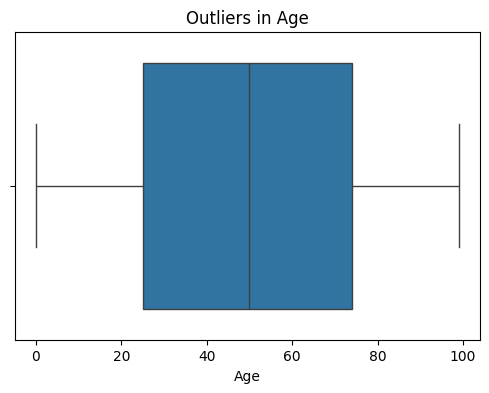

In [ ]:

# Boxplot for Age
plt.figure(figsize=(6, 4))
sns.boxplot(x=df['Age'])
plt.title('Outliers in Age')
plt.show()

In [ ]:
df['Age'].describe()

,Age
count,4500.0
mean,49.597556
std,28.663852
min,0.0
25%,25.0
50%,50.0
75%,74.0
max,99.0


In [ ]:
df['Age']=df['Age'].fillna(df['Age'].mean())
df['Age'].isnull().sum()

np.int64(0)

 Handling Missing Treatment Cos

In [ ]:
df['Treatment_Cost']=df['Treatment_Cost'].fillna(
df.groupby('Diagnosis')['Treatment_Cost'].transform('median')
)
df['Treatment_Cost'].isnull().sum()

np.int64(0)


  Outlier Detection (Treatment Cost)

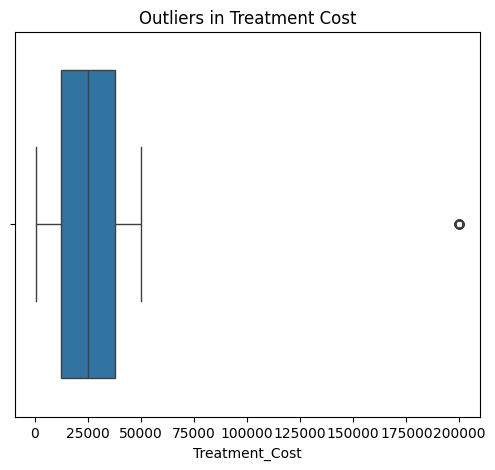

In [ ]:
plt.figure(figsize=(6,5))
sns.boxplot(x=df['Treatment_Cost'])
plt.title('Outliers in Treatment Cost')
plt.show()

In [ ]:
#  Calculate Q1  and Q3
Q1 = df['Treatment_Cost'].quantile(0.25)
Q3 = df['Treatment_Cost'].quantile(0.75)

#  Calculate IQR
IQR = Q3 - Q1


lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_cost = df[(df['Treatment_Cost'] < lower_bound) | (df['Treatment_Cost'] > upper_bound)]

print(f"Total Outliers in Treatment_Cost: {len(outliers_cost)}")
print(f"Lower Bound: {lower_bound:.2f} | Upper Bound: {upper_bound:.2f}")


outliers_cost[['Patient_ID', 'Treatment_Cost']]

Total Outliers in Treatment_Cost: 50
Lower Bound: -25638.00 | Upper Bound: 76058.00


,Patient_ID,Treatment_Cost
53,13152,199702.965333
86,10064,199702.965333
124,17035,199702.965333
183,15855,199702.965333
215,19561,199702.965333
332,11686,199702.965333
382,10876,199702.965333
416,14070,199702.965333
452,10851,199702.965333
796,18150,199702.965333


Outlier Treatment

In [ ]:
p5=df['Treatment_Cost'].quantile(0.05)
p95=df['Treatment_Cost'].quantile(0.95)

df['Treatment_Cost']=df['Treatment_Cost'].clip(lower=p5,upper=p95)

print(f'Lower Bound:{p5:.2f})|(Upper Bound:{p95:.2f}')

Lower Bound:3238.00)|(Upper Bound:47948.00


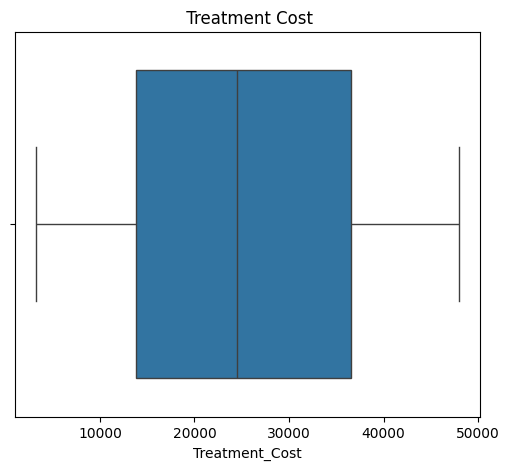

In [ ]:
plt.figure(figsize=(6,5))
sns.boxplot(x=df['Treatment_Cost'])
plt.title(' Treatment Cost')
plt.show()

/tmp/ipykernel_567/3067451769.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Diagnosis', y='Treatment_Cost', palette='Set2')


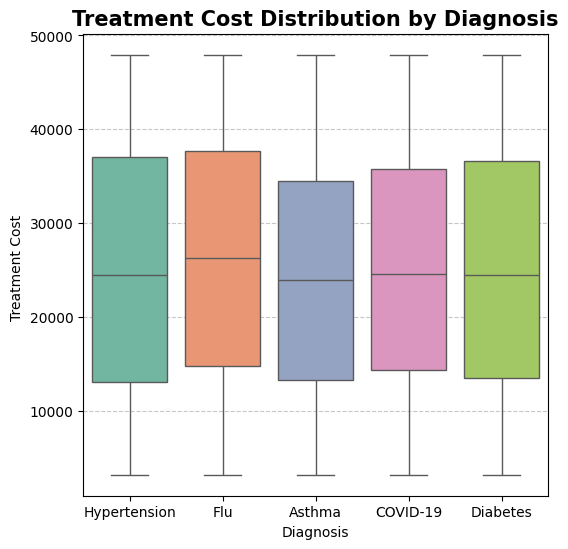

In [ ]:
plt.figure(figsize=(6, 6))
sns.boxplot(data=df, x='Diagnosis', y='Treatment_Cost', palette='Set2')

plt.title('Treatment Cost Distribution by Diagnosis', fontsize=15, fontweight='bold')
plt.xlabel('Diagnosis', fontsize=10)
plt.ylabel('Treatment Cost ', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [ ]:
df['Gender'].unique()

array(['Male', 'Female'], dtype=object)

In [ ]:
df['Insurance_Coverage'].unique()

array([1, 0])

In [ ]:
df['Diagnosis'].unique()

array(['Hypertension', 'Flu', 'Asthma', 'COVID-19', 'Diabetes'],
      dtype=object)

In [ ]:
df['Hospital_Visits'].unique()

array([13, 11,  2,  1,  5,  7,  6, 12,  8,  9, 18, 15,  3, 17, 19, 10, 14,
       16,  4])

In [ ]:
df['City'].unique()

array(['Bangalore', 'Hyderabad', 'Mumbai', 'Delhi', 'Chennai'],
      dtype=object)

In [ ]:
df.describe()

,Patient_ID,Age,Hospital_Visits,Treatment_Cost,Insurance_Coverage,Admission_Date
count,5001.000000,5001.0,5001.000000,5001.000000,5001.000000,5001
mean,14965.586883,49.637872,10.000400,25212.733353,0.489902,2023-06-30 04:00:08.638272512
min,10001.000000,0.0,1.000000,3238.000000,0.000000,2023-01-01 00:00:00
25%,12491.000000,27.0,5.000000,13766.000000,0.000000,2023-03-30 00:00:00
50%,14973.000000,50.0,10.000000,24513.500000,0.000000,2023-07-02 00:00:00
75%,17381.000000,72.0,15.000000,36542.000000,1.000000,2023-09-28 00:00:00
max,19998.000000,99.0,19.000000,47948.000000,1.000000,2023-12-31 00:00:00
std,2864.384697,27.190164,5.459157,13582.767157,0.499948,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5001 entries, 0 to 5095
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Patient_ID          5001 non-null   int64         
 1   Age                 5001 non-null   Int64         
 2   Gender              5001 non-null   object        
 3   City                5001 non-null   object        
 4   Diagnosis           5001 non-null   object        
 5   Hospital_Visits     5001 non-null   int64         
 6   Treatment_Cost      5001 non-null   float64       
 7   Insurance_Coverage  5001 non-null   int64         
 8   Admission_Date      5001 non-null   datetime64[ns]
dtypes: Int64(1), datetime64[ns](1), float64(1), int64(3), object(3)
memory usage: 395.6+ KB


In [ ]:
df.isnull().sum()

,0
Patient_ID,0
Age,0
Gender,0
City,0
Diagnosis,0
Hospital_Visits,0
Treatment_Cost,0
Insurance_Coverage,0
Admission_Date,0


Comparing Summary

In [ ]:
# Compare missing values before and after
missing_comparison = pd.DataFrame({
    'Before_Cleaning': df_copy.isnull().sum(),
    'After_Cleaning': df.isnull().sum()
})
print(" Missing Values Comparison ")
print(missing_comparison)

 Missing Values Comparison 
                    Before_Cleaning  After_Cleaning
Patient_ID                        0               0
Age                             600               0
Gender                            0               0
City                              0               0
Diagnosis                         0               0
Hospital_Visits                   0               0
Treatment_Cost                  593               0
Insurance_Coverage                0               0
Admission_Date                    0               0


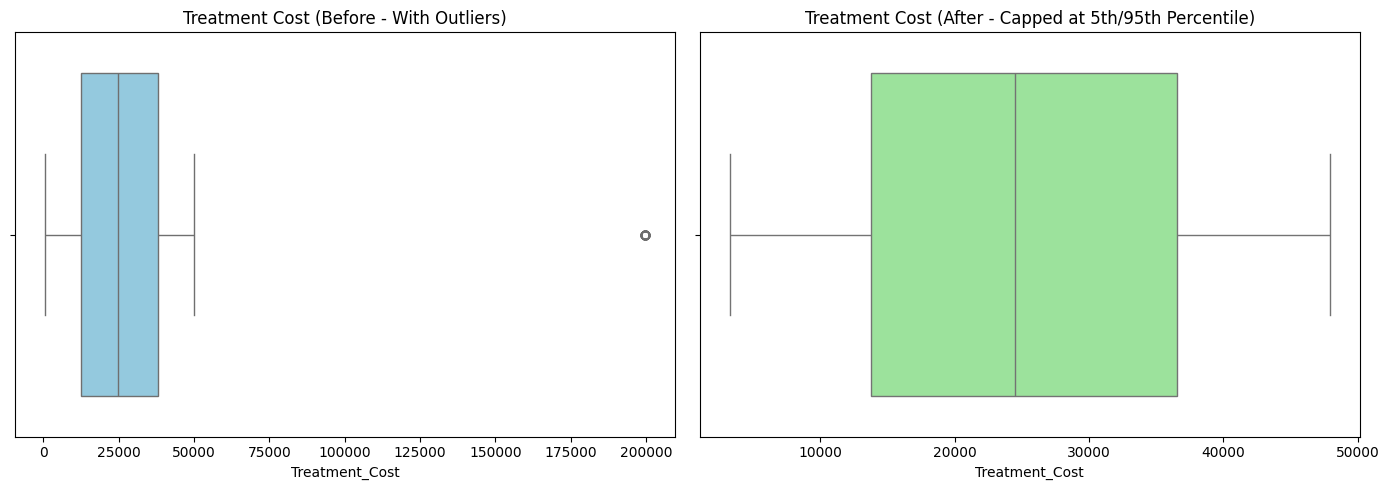

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#Before Capping
sns.boxplot(x=df_copy['Treatment_Cost'], ax=axes[0], color='skyblue')
axes[0].set_title('Treatment Cost (Before - With Outliers)')

#After Capping
sns.boxplot(x=df['Treatment_Cost'], ax=axes[1], color='lightgreen')
axes[1].set_title('Treatment Cost (After - Capped at 5th/95th Percentile)')

plt.tight_layout()
plt.show()

Data Transformation

Create the new 'Age_Group' column

In [ ]:

bins = [0, 18, 35, 50, 65, 100]
labels = ['Child ', 'Young Adult ', 'Adult ', 'Middle-Aged ', 'Senior ']


df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)


df['Age_Group'].value_counts()

,count
Age_Group,
Senior,1593
Middle-Aged,1180
Child,796
Young Adult,769
Adult,663


Categorize Treatment Cost

In [ ]:

labels=['Low cost','Medium cost','High cost','Very high cost']
df['Treatment_Cost_Group'] = pd.qcut(df['Treatment_Cost'],q=4,labels=labels)
df['Treatment_Cost_Group'].value_counts()

,count
Treatment_Cost_Group,
Medium cost,1274
Low cost,1251
Very high cost,1250
High cost,1226


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5001 entries, 0 to 5095
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Patient_ID            5001 non-null   int64         
 1   Age                   5001 non-null   Int64         
 2   Gender                5001 non-null   object        
 3   City                  5001 non-null   object        
 4   Diagnosis             5001 non-null   object        
 5   Hospital_Visits       5001 non-null   int64         
 6   Treatment_Cost        5001 non-null   float64       
 7   Insurance_Coverage    5001 non-null   int64         
 8   Admission_Date        5001 non-null   datetime64[ns]
 9   Age_Group             5001 non-null   category      
 10  Treatment_Cost_Group  5001 non-null   category      
dtypes: Int64(1), category(2), datetime64[ns](1), float64(1), int64(3), object(3)
memory usage: 405.8+ KB


Patient Frequency

In [ ]:
bins = [0, 5, 10, 15, 20]
labels = ['Infrequent', 'Occasional', 'Frequent', 'High-Utilizer']

df['Hospital_Visits_Group'] = pd.cut(df['Hospital_Visits'], bins=bins, labels=labels, right=True)

df['Hospital_Visits_Group'].value_counts()

,count
Hospital_Visits_Group,
Infrequent,1351
Frequent,1350
Occasional,1261
High-Utilizer,1039


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5001 entries, 0 to 5095
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Patient_ID             5001 non-null   int64         
 1   Age                    5001 non-null   Int64         
 2   Gender                 5001 non-null   object        
 3   City                   5001 non-null   object        
 4   Diagnosis              5001 non-null   object        
 5   Hospital_Visits        5001 non-null   int64         
 6   Treatment_Cost         5001 non-null   float64       
 7   Insurance_Coverage     5001 non-null   int64         
 8   Admission_Date         5001 non-null   datetime64[ns]
 9   Age_Group              5001 non-null   category      
 10  Treatment_Cost_Group   5001 non-null   category      
 11  Hospital_Visits_Group  5001 non-null   category      
dtypes: Int64(1), category(3), datetime64[ns](1), float64(1), int64(3), 

In [ ]:
from google.colab import files

In [ ]:
files.download('healthcare_data_transformed.csv')